# Módulo 1 — Lição de Casa (referente ao Dia 2)
## Bibliotecas Científicas & Boas Práticas de Código

Esta lição de casa reforça, com **problemas novos**, os mesmos temas do exercício em sala de hoje:
NumPy, Pandas, Matplotlib/Plotly, SciPy, documentação e Git.

**Tempo estimado:** 60–90 minutos.

**Entrega:** faça commit e push deste notebook resolvido para o mesmo repositório GitHub do
Dia 2, antes do início da aula do Dia 3. O passo a passo do Git está na última seção.

> Sempre que houver uma célula com `assert`, rode-a: se não aparecer nenhum erro, sua resposta
> está correta (ou pelo menos consistente com o esperado).

## 1. NumPy — Arrays e Vetorização

Uma estação meteorológica registrou a temperatura (°C) a cada hora, durante um dia:

In [1]:
import numpy as np

temperaturas = np.array([
    21.5, 21.0, 20.4, 20.1, 19.8, 20.0, 21.2, 23.0,
    25.4, 27.1, 28.6, 29.8, 30.5, 30.9, 30.6, 29.7,
    28.2, 26.5, 25.0, 24.1, 23.3, 22.6, 22.0, 21.6,
])
horas = np.arange(24)


### Exercício 1.1
Sem usar laços `for`, calcule:
- a temperatura média do dia
- o desvio padrão
- a temperatura máxima e em que hora ela ocorreu (dica: `np.argmax`)
- quantas horas tiveram temperatura acima de 27 °C

In [2]:
# TODO: complete os cálculos abaixo usando funções vetorizadas do NumPy
media = np.mean(temperaturas)
desvio = np.std(temperaturas)
hora_max = horas[np.argmax(temperaturas)]
temp_max = np.max(temperaturas)
horas_acima_27 = (temperaturas > 27).sum()

print(f"Média:            {media:.2f} °C")
print(f"Desvio padrão:    {desvio:.2f} °C")
print(f"Máxima:           {temp_max:.1f} °C às {hora_max}h")
print(f"Horas acima 27°C: {horas_acima_27}")


Média:            24.70 °C
Desvio padrão:    3.78 °C
Máxima:           30.9 °C às 13h
Horas acima 27°C: 8


In [3]:
# célula de autoverificação — não edite, apenas rode
assert abs(media - np.mean(temperaturas)) < 1e-9, "confira o cálculo da média"
assert abs(desvio - np.std(temperaturas)) < 1e-9, "confira o cálculo do desvio padrão"
assert temp_max == np.max(temperaturas), "confira a temperatura máxima"
assert horas_acima_27 == (temperaturas > 27).sum(), "confira a contagem de horas"
print("Exercício 1.1 OK!")


Exercício 1.1 OK!


### Exercício 1.2 — normalização

Normalize o vetor `temperaturas` para a faixa [0, 1] usando a fórmula:

$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

Isso é uma operação comum antes de usar dados como entrada de modelos (será revisitado em
módulos futuros).

In [4]:
# TODO: implemente a normalização de forma vetorizada (sem for)
temp_norm = (temperaturas - temperaturas.min()) / (temperaturas.max() - temperaturas.min())

print(temp_norm.round(2))
assert temp_norm.min() == 0.0 and temp_norm.max() == 1.0, "a normalização deveria ir de 0 a 1"
print("Exercício 1.2 OK!")


[0.15 0.11 0.05 0.03 0.   0.02 0.13 0.29 0.5  0.66 0.79 0.9  0.96 1.
 0.97 0.89 0.76 0.6  0.47 0.39 0.32 0.25 0.2  0.16]
Exercício 1.2 OK!


## 2. Pandas — Dados Tabulares

Uma dupla de alunos mediu a corrente elétrica (A) de três resistores em um experimento, em
diferentes tensões (V):

In [5]:
import pandas as pd

dados = pd.DataFrame({
    "tensao_V":   [1, 2, 3, 4, 5, 6, 7, 8],
    "corrente_R1": [0.10, 0.20, 0.31, 0.39, 0.51, 0.60, 0.71, 0.79],
    "corrente_R2": [0.05, 0.10, 0.15, 0.21, 0.24, 0.31, 0.34, 0.41],
    "corrente_R3": [0.02, 0.04, 0.06, 0.08, 0.11, 0.12, 0.14, 0.16],
})
dados


,tensao_V,corrente_R1,corrente_R2,corrente_R3
0,1,0.10,0.05,0.02
1,2,0.20,0.10,0.04
2,3,0.31,0.15,0.06
3,4,0.39,0.21,0.08
4,5,0.51,0.24,0.11
5,6,0.60,0.31,0.12
6,7,0.71,0.34,0.14
7,8,0.79,0.41,0.16


### Exercício 2.1
1. Crie uma nova coluna `resistencia_R1` com a resistência de R1 em cada linha, usando a Lei de
   Ohm (R = V / I).
2. Calcule a resistência média estimada de R1 com `.mean()`.
3. Filtre e mostre apenas as linhas em que `tensao_V` é maior que 4.

In [6]:
# TODO
dados["resistencia_R1"] = dados["tensao_V"] / dados["corrente_R1"]
resistencia_media_R1 = dados["resistencia_R1"].mean()

print(f"Resistência média estimada de R1: {resistencia_media_R1:.2f} ohms")

# TODO: filtre as linhas com tensao_V > 4
tensao_alta = dados[dados["tensao_V"] > 4]
tensao_alta


Resistência média estimada de R1: 9.97 ohms


,tensao_V,corrente_R1,corrente_R2,corrente_R3,resistencia_R1
4,5,0.51,0.24,0.11,9.803922
5,6,0.60,0.31,0.12,10.000000
6,7,0.71,0.34,0.14,9.859155
7,8,0.79,0.41,0.16,10.126582


### Exercício 2.2
Use `.describe()` para obter um resumo estatístico das três colunas de corrente de uma vez.
Qual resistor parece ter a maior resistência (menor corrente para a mesma tensão)?

In [7]:
dados[["corrente_R1", "corrente_R2", "corrente_R3"]].describe()


,corrente_R1,corrente_R2,corrente_R3
count,8.000000,8.000000,8.000000
mean,0.451250,0.226250,0.091250
std,0.244215,0.123628,0.049407
min,0.100000,0.050000,0.020000
25%,0.282500,0.137500,0.055000
50%,0.450000,0.225000,0.095000
75%,0.627500,0.317500,0.125000
max,0.790000,0.410000,0.160000


*(responda aqui, em texto: qual resistor tem a maior resistência, e por quê você chegou a
essa conclusão a partir da tabela acima?)*

**Resposta:** ...

## 3. Matplotlib & Plotly — Visualização

### Exercício 3.1
Plote a corrente de cada resistor em função da tensão, no mesmo gráfico (três curvas), usando
Matplotlib. Adicione legenda, rótulos dos eixos e título.

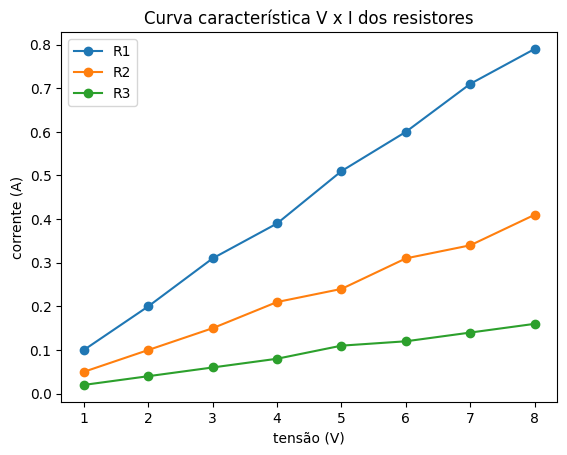

In [8]:
import matplotlib.pyplot as plt

# TODO: complete o gráfico com as três curvas (R1, R2, R3)
plt.plot(dados["tensao_V"], dados["corrente_R1"], marker="o", label="R1")
plt.plot(dados["tensao_V"], dados["corrente_R2"], marker="o", label="R2")
plt.plot(dados["tensao_V"], dados["corrente_R3"], marker="o", label="R3")
plt.xlabel("tensão (V)")
plt.ylabel("corrente (A)")
plt.title("Curva característica V x I dos resistores")
plt.legend()
plt.show()


### Exercício 3.2
Refaça o mesmo gráfico com Plotly, de forma interativa (dica: `dados` já está em formato "wide";
você pode chamar `px.line` três vezes com `fig.add_scatter`, ou usar `pd.melt` para reformatar os
dados em formato "long" — pesquise se tiver curiosidade, mas qualquer uma das duas formas está
válida).

In [9]:
import plotly.express as px

fig = px.line(dados, x="tensao_V", y=["corrente_R1", "corrente_R2", "corrente_R3"],
               markers=True,
               labels={"tensao_V": "tensão (V)", "value": "corrente (A)", "variable": "resistor"},
               title="Curva característica V x I — Plotly (interativo)")
fig.show()


## 4. SciPy — Ajuste e Otimização

### Exercício 4.1
Pela Lei de Ohm, esperamos que `corrente_R1 ≈ tensao_V / R1` (uma reta passando pela origem).
Use `scipy.optimize.curve_fit` para estimar o valor de R1 que melhor ajusta os dados observados,
e compare com a média que você calculou no Exercício 2.1.

In [10]:
from scipy.optimize import curve_fit

def modelo_ohm(V, R):
    return V / R

# TODO: ajuste o modelo aos dados de tensão e corrente de R1
parametros_otimos, _ = curve_fit(modelo_ohm, dados["tensao_V"], dados["corrente_R1"])
R1_ajustado = parametros_otimos[0]

print(f"R1 ajustado por curve_fit: {R1_ajustado:.2f} ohms")
print(f"R1 pela média (Exercício 2.1): {resistencia_media_R1:.2f} ohms")


R1 ajustado por curve_fit: 9.99 ohms
R1 pela média (Exercício 2.1): 9.97 ohms


## 5. Boas práticas — documentação

### Exercício 5.1
Escreva uma função `lei_de_ohm` que calcule a corrente dada a tensão e a resistência, **com
docstring completa** (parâmetros, retorno, e ao menos um exemplo de uso no formato mostrado em
aula).

In [11]:
def lei_de_ohm(tensao, resistencia):
    """
    TODO: complete a docstring.

    Parâmetros
    ----------
    tensao : float
        ...
    resistencia : float
        ...

    Retorna
    -------
    float
        ...
    """
    return tensao / resistencia


print(lei_de_ohm(10, 2))  # deve imprimir 5.0
assert lei_de_ohm(10, 2) == 5.0
print("Exercício 5.1 OK!")


5.0
Exercício 5.1 OK!


---
## 6. Git & GitHub — prática em casa

Ao terminar os exercícios, envie este notebook para o mesmo repositório que você criou no Dia 2
(no terminal, dentro da pasta do projeto):

```bash
git add dia2_licao_de_casa.ipynb
git commit -m "Lição de casa Dia 2: exercícios de reforço"
git push
```

Se aparecer algum erro nesse processo, revise os passos que já vimos em aula (configurar
`user.name`/`user.email`, garantir que está na pasta certa do projeto, conferir `git status`
antes do commit) — e traga a dúvida para o início da próxima aula, se precisar.

---
## Checklist final antes de entregar

- [ ] Todas as células rodam do início ao fim sem erro (`Kernel → Restart & Run All`)
- [ ] As duas células de `assert` do NumPy passaram sem erro
- [ ] A resposta em texto do Exercício 2.2 foi preenchida
- [ ] O gráfico do Exercício 3.1 tem legenda, título e rótulos nos eixos
- [ ] A docstring da função `lei_de_ohm` está completa
- [ ] O notebook foi commitado e enviado (`push`) para o GitHub